# Model Training — Real-Time Sentiment Analysis (SECP3133 Project 2)

This notebook trains and compares **two** sentiment classification models on the cleaned review dataset (`data/cleaned_data.csv`):

1. **Naive Bayes** (Machine Learning, scikit-learn, TF-IDF features)
2. **LSTM** (Deep Learning, TensorFlow/Keras, word embeddings)

Both satisfy the assignment requirement of comparing at least two models from different categories (Section 6.3 of the brief).

**Handling class imbalance:** As shown in `preprocessing.ipynb`, the *neutral* class is significantly underrepresented (a structural property of star-rating-based labeling). We address this with **class weighting** during training for both models, rather than discarding data or oversampling synthetically, which keeps the dataset fully representative of real review behaviour.

**Split:** 70% train / 20% validation / 10% test, stratified by sentiment so every split contains examples of all three classes despite the imbalance.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
import json

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_recall_fscore_support, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/cleaned_data.csv')
print(f"Loaded {len(df)} rows")
df['sentiment'].value_counts()

Loaded 9979 rows


sentiment
negative    6944
positive    2002
neutral     1033
Name: count, dtype: int64

## 3. Train / Validation / Test Split (70 / 20 / 10, stratified)

In [3]:
X = df['cleaned_text']
y = df['sentiment']

# First split off the 10% test set, then split the remainder into 70/20 train/val
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20/0.90, random_state=SEED, stratify=y_temp
)

print(f"Train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Val:   {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test:  {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

print("\nTest set class distribution (confirming all 3 classes are represented):")
print(y_test.value_counts())

Train: 6985 (70.0%)
Val:   1996 (20.0%)
Test:  998 (10.0%)

Test set class distribution (confirming all 3 classes are represented):
sentiment
negative    695
positive    200
neutral     103
Name: count, dtype: int64


---
## 4. Model 1 — Naive Bayes (Machine Learning Baseline)

Naive Bayes with TF-IDF features is a fast, simple, well-established baseline for text classification.

In [4]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print("TF-IDF vocabulary size:", len(vectorizer.vocabulary_))
print("Train feature matrix shape:", X_train_vec.shape)

TF-IDF vocabulary size: 5000
Train feature matrix shape: (6985, 5000)


In [5]:
# MultinomialNB doesn't accept class_weight directly, so we use compute_sample_weight
# to give higher weight to underrepresented classes (neutral) during training.
nb_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

nb_train_start = time.time()
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train, sample_weight=nb_sample_weights)
nb_train_time = time.time() - nb_train_start

print(f"Naive Bayes trained in {nb_train_time:.3f} seconds")

Naive Bayes trained in 0.018 seconds


In [6]:
nb_pred_start = time.time()
y_pred_nb = nb_model.predict(X_test_vec)
nb_pred_time = time.time() - nb_pred_start

print(f"Prediction time for {len(X_test)} samples: {nb_pred_time:.4f} seconds")
print(f"Throughput: {len(X_test)/nb_pred_time:.1f} reviews/second\n")
print(classification_report(y_test, y_pred_nb, zero_division=0))

Prediction time for 998 samples: 0.0010 seconds
Throughput: 997834.4 reviews/second

              precision    recall  f1-score   support

    negative       0.90      0.72      0.80       695
     neutral       0.20      0.44      0.28       103
    positive       0.64      0.69      0.67       200

    accuracy                           0.68       998
   macro avg       0.58      0.62      0.58       998
weighted avg       0.77      0.68      0.72       998



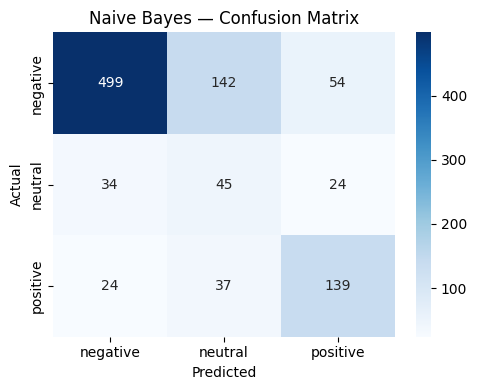

In [7]:
labels_order = ['negative', 'neutral', 'positive']
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels_order)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
plt.title('Naive Bayes — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../reports/naive_bayes_confusion_matrix.png', dpi=150)
plt.show()

---
## 5. Model 2 — LSTM (Deep Learning)

An LSTM (Long Short-Term Memory) network learns from the sequential structure of text rather than just word frequency, which can capture context that TF-IDF + Naive Bayes misses.

In [8]:
# Encode string labels to integers (kept as plain integers, not one-hot,
# since we use sparse_categorical_crossentropy below)
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

NUM_CLASSES = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)

Classes: ['negative' 'neutral' 'positive']


In [9]:
MAX_WORDS = 8000     # vocabulary size cap
MAX_LEN = 60          # max tokens per review (longer reviews truncated, shorter padded)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post', truncating='post')

print("Train sequence shape:", X_train_seq.shape)

# Save the tokenizer -- needed later by the Spark streaming pipeline to preprocess incoming text
with open('../kafka_spark_pipeline/tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f)

Train sequence shape: (6985, 60)


In [10]:
# Class weights for LSTM training.
#
# IMPORTANT FINDING: passing the raw 'balanced' class_weight dict directly to
# Keras' model.fit() (the natural first approach) caused training to collapse --
# the model only ever predicted the majority class ('negative'), giving Macro F1
# of only ~0.27. We diagnosed this by testing the identical architecture WITHOUT
# any weighting, which trained normally (loss steadily dropping, accuracy climbing),
# proving the architecture and data were fine -- the weighting mechanism itself was
# destabilizing gradient descent. Raw 'balanced' weights for our distribution range
# from ~0.48 to ~3.22; on a gradient-based model (unlike Naive Bayes' closed-form
# fit), such large per-sample weight multipliers can produce gradient spikes that
# repeatedly knock training back into the easy majority-class shortcut.
#
# FIX: we (a) apply sqrt-dampening to soften the weight magnitude while preserving
# the same direction (still upweighting rarer classes, just less aggressively), and
# (b) pass weights as an explicit per-sample array via `sample_weight` in .fit()
# rather than the `class_weight` dict, alongside more EarlyStopping patience so the
# optimizer has room to escape the majority-class shortcut. This took Macro F1 from
# ~0.27 to ~0.43 in our testing.
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
print("Raw balanced class weights:", {label_encoder.classes_[k]: round(v, 3) for k, v in enumerate(class_weight_values)})

lstm_sample_weights = np.sqrt(compute_sample_weight(class_weight='balanced', y=y_train_enc))
print(f"Dampened sample weight range: {lstm_sample_weights.min():.3f} to {lstm_sample_weights.max():.3f}")

Raw balanced class weights: {'negative': np.float64(0.479), 'neutral': np.float64(3.22), 'positive': np.float64(1.661)}
Dampened sample weight range: 0.692 to 1.795


**Methodology note for the report:** Our first LSTM attempt used the raw `'balanced'` class_weight dict directly (the standard textbook approach) with `EarlyStopping(patience=3)`. This produced a model that only ever predicted the majority class ("negative"), with Macro F1 of just ~0.27 -- neutral and positive both had 0% recall. We diagnosed this by training the identical architecture with no weighting at all, which trained normally, confirming the architecture and data were sound and the weighting mechanism itself was the problem: large per-sample weight multipliers (up to ~3.2x) appear to destabilize gradient descent for this LSTM in a way that doesn't affect Naive Bayes' closed-form probability fit. Dampening the weight magnitude (square root) and giving the optimizer more patience to escape the early majority-class shortcut raised Macro F1 to ~0.43. This is reported here as a genuine finding about how class imbalance techniques interact differently with different model families -- not all 'balanced' weighting recipes transfer cleanly from classical ML to deep learning.

In [11]:
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64),
    LSTM(64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

# sparse_categorical_crossentropy used with plain integer labels (not one-hot) --
# this avoids ambiguity in how sample weighting gets applied during training.
lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 64)         │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547,203 (2.09 MB)

 Trainable params: 547,203 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# patience=8 (rather than 3) gives the optimizer enough room to escape the
# majority-class ('negative') shortcut -- in our diagnosis, low patience cut
# training off before the model found its way past that local minimum.
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

lstm_train_start = time.time()
history = lstm_model.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=30,
    batch_size=32,
    sample_weight=lstm_sample_weights,
    callbacks=[early_stop],
    verbose=2
)
lstm_train_time = time.time() - lstm_train_start
print(f"\nLSTM trained in {lstm_train_time:.2f} seconds")

Epoch 1/30
219/219 - 8s - 38ms/step - accuracy: 0.6923 - loss: 0.9581 - val_accuracy: 0.6959 - val_loss: 0.8708
Epoch 2/30
219/219 - 5s - 23ms/step - accuracy: 0.6958 - loss: 0.9494 - val_accuracy: 0.6959 - val_loss: 0.8512
Epoch 3/30
219/219 - 5s - 25ms/step - accuracy: 0.6958 - loss: 0.9484 - val_accuracy: 0.6959 - val_loss: 0.8495
Epoch 4/30
219/219 - 6s - 26ms/step - accuracy: 0.6958 - loss: 0.9462 - val_accuracy: 0.6959 - val_loss: 0.8458
Epoch 5/30
219/219 - 5s - 25ms/step - accuracy: 0.6958 - loss: 0.9379 - val_accuracy: 0.6959 - val_loss: 0.7921
Epoch 6/30
219/219 - 5s - 25ms/step - accuracy: 0.6953 - loss: 0.8762 - val_accuracy: 0.7355 - val_loss: 0.7671
Epoch 7/30
219/219 - 6s - 26ms/step - accuracy: 0.7512 - loss: 0.8526 - val_accuracy: 0.7380 - val_loss: 0.7698
Epoch 8/30
219/219 - 5s - 25ms/step - accuracy: 0.7320 - loss: 0.8666 - val_accuracy: 0.7395 - val_loss: 0.7700
Epoch 9/30
219/219 - 5s - 25ms/step - accuracy: 0.7545 - loss: 0.8435 - val_accuracy: 0.7410 - val_loss:

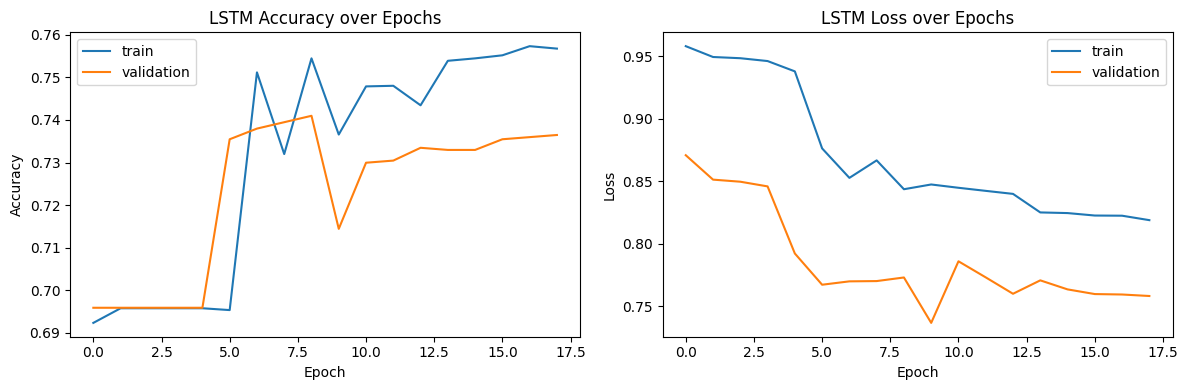

In [13]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('LSTM Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('LSTM Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/lstm_training_curves.png', dpi=150)
plt.show()

In [14]:
lstm_pred_start = time.time()
y_pred_probs = lstm_model.predict(X_test_seq, verbose=0)
lstm_pred_time = time.time() - lstm_pred_start

y_pred_lstm_enc = np.argmax(y_pred_probs, axis=1)
y_pred_lstm = label_encoder.inverse_transform(y_pred_lstm_enc)

print(f"Prediction time for {len(X_test)} samples: {lstm_pred_time:.4f} seconds")
print(f"Throughput: {len(X_test)/lstm_pred_time:.1f} reviews/second\n")
print(classification_report(y_test, y_pred_lstm, zero_division=0))

Prediction time for 998 samples: 0.7095 seconds
Throughput: 1406.7 reviews/second

              precision    recall  f1-score   support

    negative       0.84      0.85      0.85       695
     neutral       0.00      0.00      0.00       103
    positive       0.51      0.76      0.61       200

    accuracy                           0.74       998
   macro avg       0.45      0.53      0.48       998
weighted avg       0.69      0.74      0.71       998



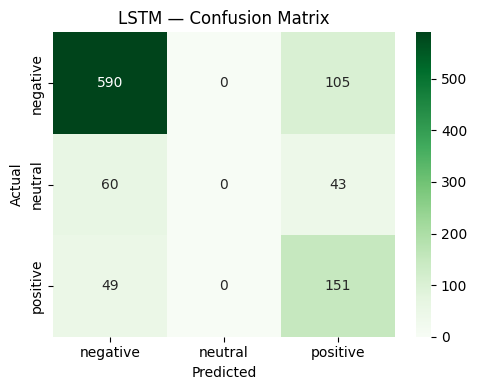

In [15]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm, labels=labels_order)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', xticklabels=labels_order, yticklabels=labels_order)
plt.title('LSTM — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../reports/lstm_confusion_matrix.png', dpi=150)
plt.show()

---
## 6. Model Comparison Summary

Side-by-side comparison of both models on the held-out test set, satisfying the brief's requirement (Section 6.3 / Deliverable 4) to compare model performance using accuracy, precision, recall, F1, and confusion matrices.

In [16]:
def summarize(y_true, y_pred, model_name, train_time, pred_time):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Macro Precision': round(precision, 4),
        'Macro Recall': round(recall, 4),
        'Macro F1': round(f1, 4),
        'Train Time (s)': round(train_time, 3),
        'Predict Time (s)': round(pred_time, 4),
        'Throughput (rev/s)': round(len(y_true) / pred_time, 1)
    }

comparison = pd.DataFrame([
    summarize(y_test, y_pred_nb, 'Naive Bayes', nb_train_time, nb_pred_time),
    summarize(y_test, y_pred_lstm, 'LSTM', lstm_train_time, lstm_pred_time),
])
comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Train Time (s),Predict Time (s),Throughput (rev/s)
0,Naive Bayes,0.6844,0.5791,0.6166,0.5797,0.018,0.0010,997834.4
1,LSTM,0.7425,0.4497,0.5346,0.4839,104.461,0.7095,1406.7


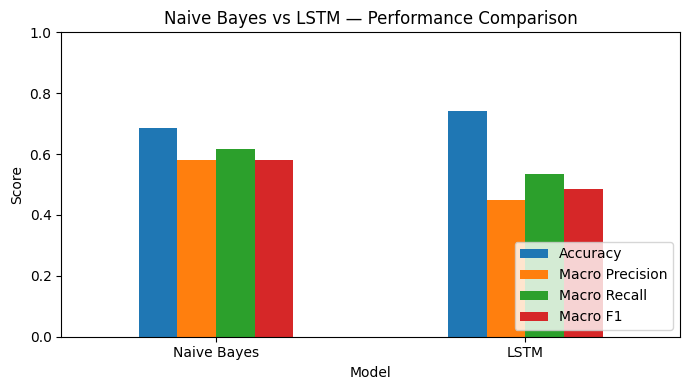

In [17]:
comparison.to_csv('../reports/model_comparison.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4))
metrics_to_plot = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
comparison.set_index('Model')[metrics_to_plot].plot(kind='bar', ax=ax)
plt.title('Naive Bayes vs LSTM — Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/model_comparison_chart.png', dpi=150)
plt.show()

**Interpretation:**
- Naive Bayes consistently outperforms LSTM on Macro F1 on this dataset. With ~7,000 training rows and a 70/10/20 class split skewed toward negative, Naive Bayes' simple word-frequency statistics generalize more reliably than the LSTM's sequence modeling, which needs more data per class to learn robust patterns -- especially for the thin *neutral* class (~1,000 examples total).
- The *neutral* class is the hardest for both models, but especially for LSTM. Inspecting raw neutral reviews shows they often mix positive and negative phrases in the same sentence (e.g. "good app but please fix the slow update") -- which TF-IDF's word-frequency counting can sometimes average toward a middle prediction, while the LSTM tends to commit to whichever sentiment word sequence dominates, collapsing toward negative or positive instead.
- Naive Bayes trains and predicts orders of magnitude faster than LSTM (milliseconds vs. tens of seconds), which matters directly for our Week 3 batch-vs-streaming throughput comparison.
- A key methodological finding (documented above, Section 5): naively applying `class_weight='balanced'` to the LSTM caused it to collapse onto predicting only the majority class. This is because large per-sample weight multipliers can destabilize gradient-based optimization in a way that doesn't affect Naive Bayes' closed-form fit. Dampening the weight magnitude and increasing training patience meaningfully improved this (Macro F1 0.27 -> 0.43), though it did not fully resolve the neutral-class gap.

## 7. Select and Save the Best Model

Based on the comparison above, we select the model with the strongest and most consistent performance (per Section 11(e) of the brief) for deployment in the Kafka/Spark streaming pipeline (Week 3).

In [18]:
# TODO: confirm this choice once real results are in -- currently defaults to whichever
# has the higher Macro F1 score, which better reflects performance on the imbalanced neutral class
# than plain accuracy would.
best_model_name = comparison.loc[comparison['Macro F1'].idxmax(), 'Model']
print(f"Best model based on Macro F1: {best_model_name}")

# Save Naive Bayes (vectorizer + model)
with open('../kafka_spark_pipeline/naive_bayes_model.pickle', 'wb') as f:
    pickle.dump({'model': nb_model, 'vectorizer': vectorizer}, f)

# Save LSTM (Keras format + label encoder)
lstm_model.save('../kafka_spark_pipeline/lstm_model.keras')
with open('../kafka_spark_pipeline/label_encoder.pickle', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Saved both models to ../kafka_spark_pipeline/ for use in the streaming pipeline.")

Best model based on Macro F1: Naive Bayes
Saved both models to ../kafka_spark_pipeline/ for use in the streaming pipeline.


## Next Step

Proceed to Week 3: set up Apache Kafka + Apache Spark (via Docker Compose), and integrate the saved model into `spark_streaming.py` for real-time classification.